In [16]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

In [17]:
#dataset load
df = pd.read_csv("loan_data.csv")

print(df.head())

   Gender Married     Education  ApplicantIncome  CoapplicantIncome  \
0    Male     Yes      Graduate             5000                  0   
1    Male     Yes      Graduate             3000               1500   
2  Female      No      Graduate             2500                  0   
3    Male     Yes  Not Graduate             1800               1000   
4  Female      No      Graduate             4000                  0   

   LoanAmount  Credit_History Property_Area Loan_Status  
0         120               1         Urban           Y  
1         100               1         Rural           Y  
2          90               1     Semiurban           Y  
3          80               0         Rural           N  
4         110               1         Urban           Y  


In [3]:
#analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             104 non-null    object
 1   Married            104 non-null    object
 2   Education          104 non-null    object
 3   ApplicantIncome    104 non-null    int64 
 4   CoapplicantIncome  104 non-null    int64 
 5   LoanAmount         104 non-null    int64 
 6   Credit_History     104 non-null    int64 
 7   Property_Area      104 non-null    object
 8   Loan_Status        104 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.4+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History
count,104.000000,104.000000,104.000000,104.000000
mean,3060.576923,475.961538,96.538462,0.701923
std,1123.916373,553.803300,15.073878,0.459629
min,1500.000000,0.000000,70.000000,0.000000
25%,2000.000000,0.000000,85.000000,0.000000
50%,2900.000000,250.000000,97.500000,1.000000
75%,4000.000000,1000.000000,110.000000,1.000000
max,5000.000000,1500.000000,120.000000,1.000000


In [5]:
#missing value
df.isnull().sum()

Gender               0
Married              0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [6]:
#encode
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df["Married"] = le.fit_transform(df["Married"])

df["Education"] = le.fit_transform(df["Education"])

df["Property_Area"] = le.fit_transform(df["Property_Area"])

df["Loan_Status"] = le.fit_transform(df["Loan_Status"])

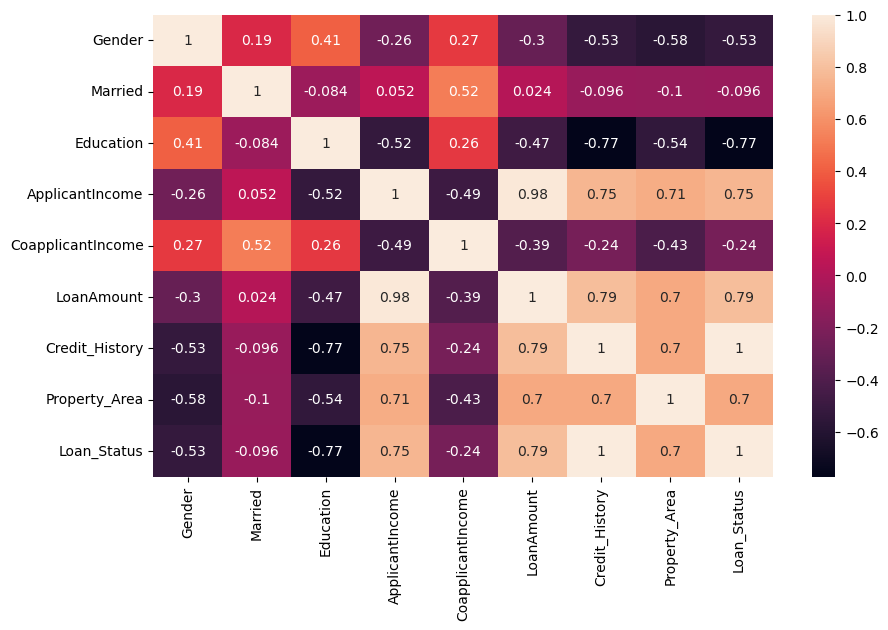

In [7]:
#heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

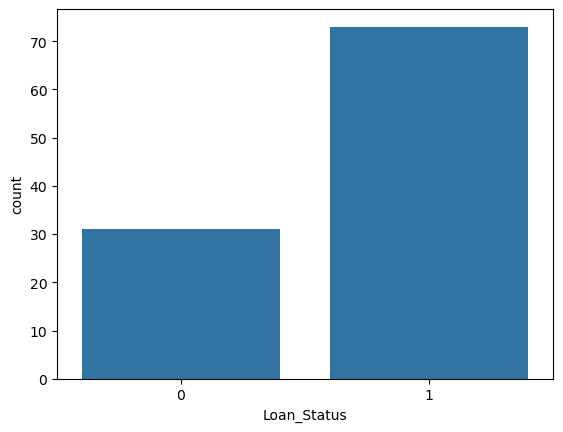

In [8]:
#count
sns.countplot(
    x="Loan_Status",
    data=df
)

plt.show()

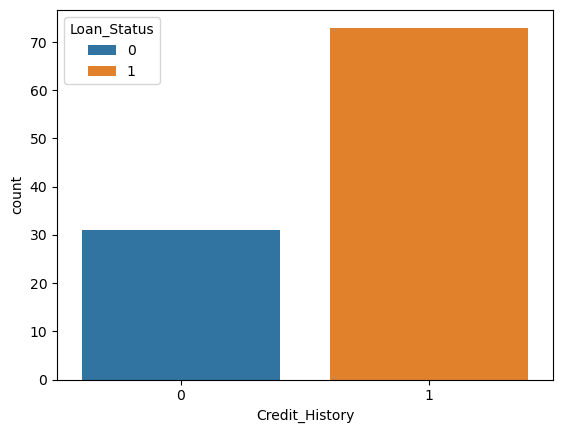

In [9]:
sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.show()

In [10]:
#features
X = df[
[
"Gender",
"Married",
"Education",
"ApplicantIncome",
"CoapplicantIncome",
"LoanAmount",
"Credit_History",
"Property_Area"
]
]

y = df["Loan_Status"]

In [11]:
#train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
#logistic regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

print(
    accuracy_score(
        y_test,
        prediction
    )
)

1.0


In [13]:
#random forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred
    )
)

1.0


In [14]:
#confusion matrix
print(
    confusion_matrix(
        y_test,
        pred
    )
)

[[ 7  0]
 [ 0 14]]


In [15]:
#classfication
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        14

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [18]:
#KNN
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 1.0


In [19]:
#Decision tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


In [20]:
#SVM
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 1.0


In [24]:
#Accuracy comparision
results = pd.DataFrame({
    "Model":[
        "KNN",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results)

           Model  Accuracy
0            KNN       1.0
1  Decision Tree       1.0
2            SVM       1.0


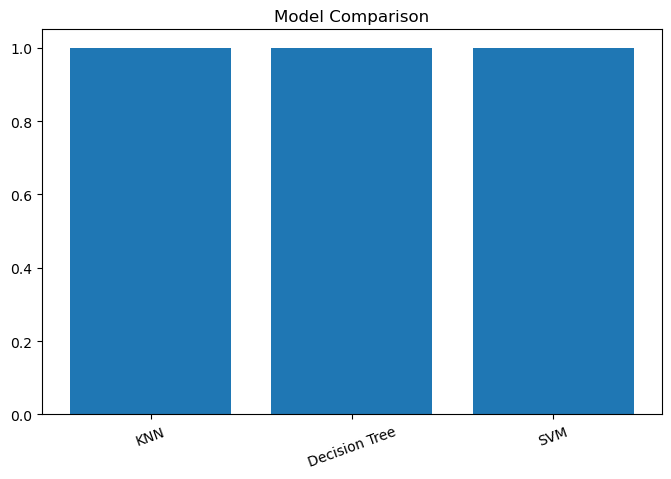

In [25]:
#accuracy graph
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()